# Radar signal processing 

## Target Detection in FMCW Radar using FFT

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift
from scipy.signal import windows

### Radar Parameters

In [ ]:
c = 3e8
fc = 77e9
B = 150e6
Tchirp = 40e-6
Nd = 128
Nr = 1024
Na = 8               

fs = Nr / Tchirp

### Targets: (range m, velocity m/s, angle deg)

In [3]:
targets = [
    (50, 30, 20),
    (120, -25, -15),
    (200, 40, 35),
    (1000, 0, 0)
]

### Derived Parameters

In [ ]:
slope = B / Tchirp
lambda_c = c / fc
d = lambda_c / 2  

### Time vector

In [5]:
t = np.linspace(0, Nd*Tchirp, Nd*Nr)

### Transmitted Signal

In [6]:
Tx = np.cos(2*np.pi*(fc*t + slope*t*t/2))

### Received Signal cube (Antennas × Chirps × Samples)

In [7]:
Rx = np.zeros((Na, Nd*Nr))

for R, v, ang in targets:

    delay = 2 * R / c
    doppler = 2 * v / lambda_c
    ang_rad = np.deg2rad(ang)

    for a in range(Na):
        phase = 2*np.pi * a * d * np.sin(ang_rad) / lambda_c

        Rx[a] += np.cos(2*np.pi*(fc*(t-delay) +
                     slope*(t-delay)**2/2 + doppler*t) + phase)

### Mix

In [8]:
Mix = Tx * Rx
Mix = Mix.reshape(Na, Nd, Nr)

### Windowing

In [9]:
window = windows.hamming(Nr)
Mix = Mix * window

### 1st FFT: Range

In [10]:
range_fft = np.abs(fft(Mix, axis=2))
range_fft = range_fft[:, :, :Nr//2]

### 2nd FFT: Doppler

In [11]:
doppler_fft = fftshift(fft(range_fft, axis=1), axes=1)

### 3rd FFT: Angle

In [12]:
angle_fft = fftshift(fft(doppler_fft, axis=0), axes=0)
angle_map = np.abs(angle_fft)

### Axes

In [13]:
range_axis = np.linspace(0, (c*Tchirp*fs)/(2*B), Nr//2)
doppler_axis = np.linspace(-Nd/2, Nd/2, Nd)
angle_axis = np.linspace(-90, 90, Na)

### Plot Range FFT (first antenna)

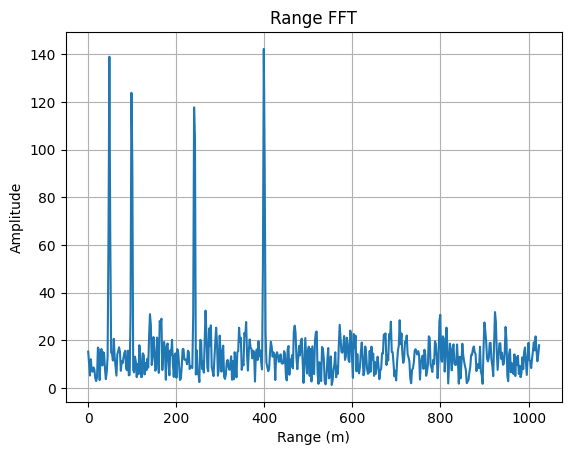

In [14]:
plt.figure()
plt.plot(range_axis, range_fft[0,0])
plt.title("Range FFT")
plt.xlabel("Range (m)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

### Plot Range Doppler Map (first antenna)

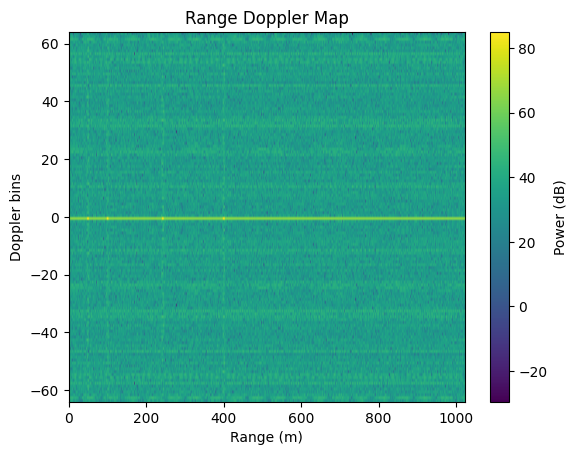

In [15]:
RDM = 20*np.log10(np.abs(doppler_fft[0]) + 1e-6)

plt.figure()
plt.imshow(RDM, aspect='auto',
           extent=[range_axis.min(), range_axis.max(),
                   doppler_axis.min(), doppler_axis.max()])
plt.title("Range Doppler Map")
plt.xlabel("Range (m)")
plt.ylabel("Doppler bins")
plt.colorbar(label="Power (dB)")
plt.show()

### Angle Estimation

Estimated dominant angle: 12.86 degrees


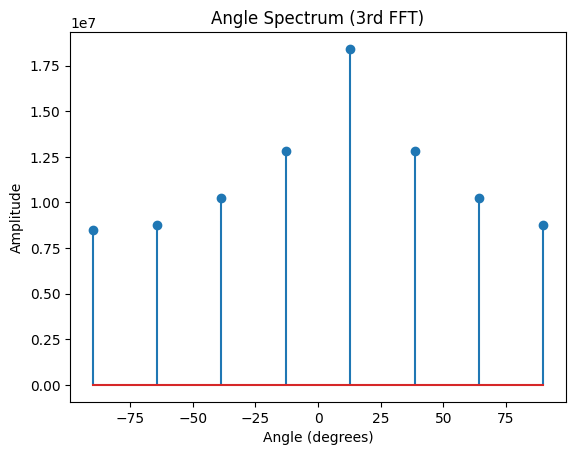

In [16]:
angle_profile = np.sum(angle_map, axis=(1,2))
peak = np.argmax(angle_profile)

print("Estimated dominant angle:", round(angle_axis[peak],2), "degrees")

plt.figure()
plt.stem(angle_axis, angle_profile)
plt.title("Angle Spectrum (3rd FFT)")
plt.xlabel("Angle (degrees)")
plt.ylabel("Amplitude")
plt.show()

Radar Targets (range, angle):
240.5 m , 12.9 deg
98.2 m , 12.9 deg
48.1 m , 12.9 deg
398.8 m , 12.9 deg


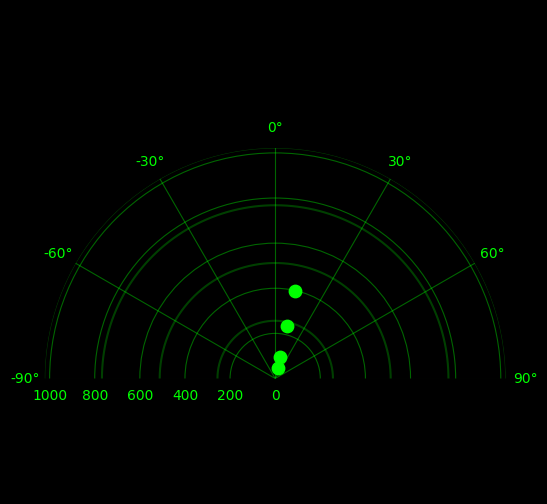

In [17]:
from matplotlib.animation import FuncAnimation

# Simple target extraction (top peaks in Range FFT)
# Use first antenna + first chirp
range_profile = range_fft[0,0]

# Find strongest peaks (very simple method)
peak_indices = np.argsort(range_profile)[-4:]

detected_ranges = range_axis[peak_indices]

# Use dominant angle from 3rd FFT
detected_angle = angle_axis[peak]

# Build radar targets (range + same angle for demo)
radar_targets = [(r, detected_angle) for r in detected_ranges]

print("Radar Targets (range, angle):")
for r,a in radar_targets:
    print(round(r,1), "m ,", round(a,1), "deg")

# Radar Display (-90 to +90 degrees)
max_range = range_axis.max()

target_r = [t[0] for t in radar_targets]
target_theta = [np.deg2rad(t[1]) for t in radar_targets]

fig = plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.set_ylim(0, max_range)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Bright grid
ax.grid(color="lime", alpha=0.4)
ax.tick_params(colors="lime")

# Range arcs
for r in np.linspace(0, max_range, 5)[1:]:
    ax.plot(np.linspace(-np.pi/2, np.pi/2, 300),
            [r]*300, color="lime", alpha=0.25)

# Plot detected targets
ax.scatter(target_theta, target_r, c="lime", s=80)

# Sweep + glow
sweep, = ax.plot([], [], color="lime", linewidth=3)
glow1, = ax.plot([], [], color="lime", linewidth=8, alpha=0.15)
glow2, = ax.plot([], [], color="lime", linewidth=14, alpha=0.07)
cone = ax.fill([], [], color="lime", alpha=0.25)[0]

angles = np.linspace(-90, 90, 200)

def update(i):
    ang = np.deg2rad(angles[i])

    sweep.set_data([ang, ang], [0, max_range])
    glow1.set_data([ang, ang], [0, max_range])
    glow2.set_data([ang, ang], [0, max_range])

    cone_ang = np.linspace(ang-0.18, ang+0.18, 40)
    cone_r = np.ones_like(cone_ang) * max_range
    cone.set_xy(np.column_stack([cone_ang, cone_r]))

    return sweep, glow1, glow2, cone

ani = FuncAnimation(fig, update, frames=len(angles), interval=40)

plt.title("Radar Display (-90° to +90°)")
plt.show()